# Time-resolved letter decoding - accuracy over time, per letter

## Configuration and imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

TRUE_GLOB    = "../../FC_letter_decoding_updated/v2/Results/single_letter_50_{k}.npy"
SHUFFLE_GLOB = "../../FC_letter_decoding_updated/v2/Results/single_letter_shuffle_{k}.npy"
LETTERS_NPY  = "../Data/letters.npy"         
OUTPUT_DIR   = "."                     

N_TRUE_RUNS    = 50     
N_SHUFFLE_RUNS = 200  
N_LETTERS      = 15

BIN_WIDTH_S = 0.5      
TIME_START  = -6.0      
T1, T2      = 2, 16     

LETTERS_FALLBACK = ['B','C','D','F','G','H','K','L','N','P','R','S','T','V','Z']

mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.family": "sans-serif",
    "axes.linewidth": 0.8,
    "xtick.direction": "out", "ytick.direction": "out",
})

In [2]:
def load_diag_stack(path_template, n_runs, n_letters):
    '''Load runs and return the per-time-point accuracy stack.

    Returns
    -------
    stack   : (n_found_runs, n_letters, n_times) array of diagonal accuracies.
    n_found : int, how many run files were successfully loaded.
    '''
    runs, n_found = [], 0
    for k in range(n_runs):
        path = path_template.format(k=k)
        if not os.path.exists(path):
            continue
        maps = np.load(path, allow_pickle=True)          # (n_letters, n_win, n_win)
        per_letter = [np.diag(np.asarray(maps[i], dtype=float))
                      for i in range(n_letters)]          # each -> (n_times,)
        runs.append(np.array(per_letter))                # (n_letters, n_times)
        n_found += 1
    if n_found == 0:
        return None, 0
    return np.array(runs), n_found                        # (n_runs, n_letters, n_times)


letter_acc,         n_true = load_diag_stack(TRUE_GLOB,    N_TRUE_RUNS,    N_LETTERS)
letter_shuffle_acc, n_shuf = load_diag_stack(SHUFFLE_GLOB, N_SHUFFLE_RUNS, N_LETTERS)


_letters = np.load(LETTERS_NPY)
uniqueLetters = np.array([p for p in np.unique(_letters) if p not in ['Q', 'W', 'X']])

n_times = letter_acc.shape[-1]
time_s  = TIME_START + np.arange(n_times) * BIN_WIDTH_S   # left edge of each bin

print(f"true stack    letter_acc.shape         = {letter_acc.shape}   (runs found: {n_true})")
print(f"shuffle stack letter_shuffle_acc.shape = {letter_shuffle_acc.shape}   (runs found: {n_shuf})")
print(f"n_times = {n_times}  ->  time axis {time_s[0]:.2f} .. {time_s[-1]:.2f} s "
      f"(bin width {BIN_WIDTH_S}s; bins span up to {time_s[-1]+BIN_WIDTH_S:.2f} s)")
print(f"analysis window = bins {T1}..{T2}  ->  {time_s[T1]:.2f} .. {time_s[T2-1]:.2f} s")
print(f"letters = {list(uniqueLetters)}")

true stack    letter_acc.shape         = (50, 15, 16)   (runs found: 50)
shuffle stack letter_shuffle_acc.shape = (200, 15, 16)   (runs found: 200)
n_times = 16  ->  time axis -6.00 .. 1.50 s (bin width 0.5s; bins span up to 2.00 s)
analysis window = bins 2..16  ->  -5.00 .. 1.50 s
letters = ['B', 'C', 'D', 'F', 'G', 'H', 'K', 'L', 'N', 'P', 'R', 'S', 'T', 'V', 'Z']


## 3  Time-resolved decoding

In [3]:
true_median = np.median(letter_acc, axis=0)                 # (n_letters, n_times)

# per-letter shuffle band
shuf_p05_letter = np.percentile(letter_shuffle_acc, 5,  axis=0)   # (n_letters, n_times)
shuf_p95_letter = np.percentile(letter_shuffle_acc, 95, axis=0)

print("true_median.shape :", true_median.shape)

true_median.shape : (15, 16)


In [4]:
def benjamini_hochberg(pvals):
    '''BH FDR-adjusted p-values (q-values). Same routine as the original notebook.'''
    p = np.asarray(pvals, dtype=float)
    m = p.size
    order = np.argsort(p)
    ranked = p[order]
    q = np.empty_like(ranked)
    prev = 1.0
    for i in range(m-1, -1, -1):
        prev = min(prev, ranked[i]*m/(i+1))
        q[i] = prev
    out = np.empty_like(q)
    out[order] = q
    return out

def percentile_p_two_sided(true_vals, shuffle_vals):
    xbar = float(np.median(true_vals))
    s = np.asarray(shuffle_vals, dtype=float); n = s.size
    p_ge = (np.sum(s >= xbar)+1)/(n+1)
    p_le = (np.sum(s <= xbar)+1)/(n+1)
    return min(1.0, 2.0*min(p_ge, p_le))

def percentile_p_upper(true_val, shuffle_vals):
    '''One-sided upper p-value: is true_val above the null?'''
    s = np.asarray(shuffle_vals, dtype=float)
    return (np.sum(s >= float(true_val))+1)/(s.size+1)

def sig_stars(q):
    if q < 0.001: return '***'
    if q < 0.01:  return '**'
    if q < 0.05:  return '*'
    return ''

T = T2 - T1
ALPHA = 0.05

# ---- overall per-letter significance (matches the main figure's estimator) ----
last_true = np.array([
    np.cumsum(letter_acc[:, i, T1:T2], axis=-1)[:, -1] / T for i in range(N_LETTERS)])
last_shuffle = np.array([
    np.cumsum(letter_shuffle_acc[:, i, T1:T2], axis=-1)[:, -1] / T for i in range(N_LETTERS)])
overall_p = np.array([percentile_p_two_sided(last_true[i], last_shuffle[i])
                      for i in range(N_LETTERS)])
overall_q = benjamini_hochberg(overall_p)
is_sig_overall = overall_q < ALPHA

# ---- time-resolved per-letter x time significance (ALL bins) ------------------
tr_p = np.ones((N_LETTERS, n_times))
for i in range(N_LETTERS):
    for t in range(n_times):
        tr_p[i, t] = percentile_p_upper(true_median[i, t], letter_shuffle_acc[:, i, t])

flat_idx = [(i, t) for i in range(N_LETTERS) for t in range(n_times)]
flat_q   = benjamini_hochberg([tr_p[i, t] for (i, t) in flat_idx])
tr_q = np.ones((N_LETTERS, n_times))
for (i, t), q in zip(flat_idx, flat_q):
    tr_q[i, t] = q

is_sig_time      = tr_q < ALPHA     # BH-corrected  (n_letters, n_times)
is_sig_time_unc  = tr_p < ALPHA     # uncorrected

order = np.argsort(np.median(last_true, axis=1))[::-1]

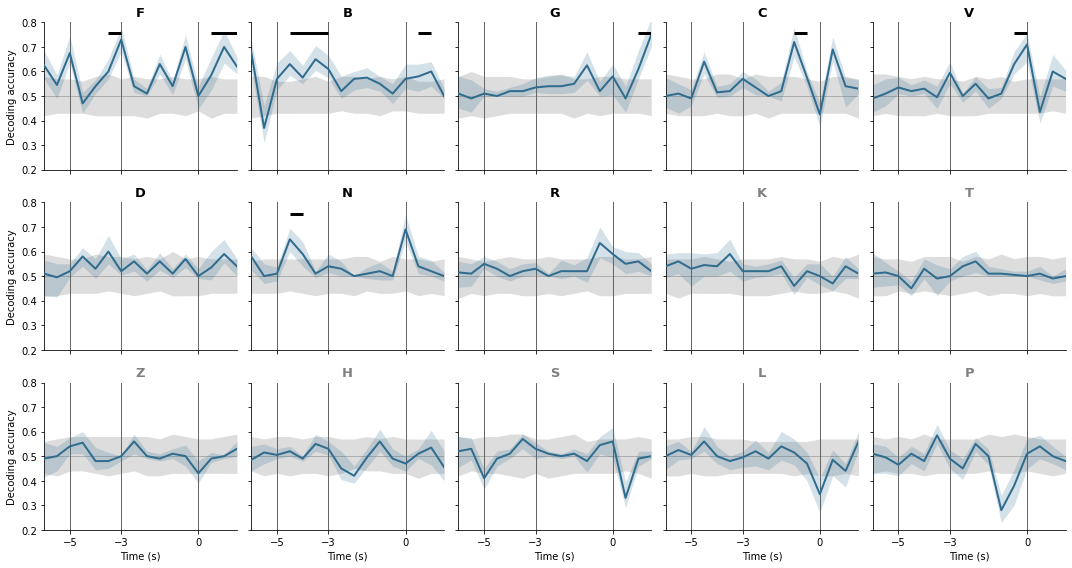

In [7]:
WIN_T1, WIN_T2 = 0, n_times
sl = slice(WIN_T1, WIN_T2)

CHANCE            = 0.5
CLUSTER_STAT      = "lenght"    # "mass" (sum of acc-CHANCE over the run) or "length"

true_p05_letter = np.percentile(letter_acc, 5,  axis=0)          # (n_letters, n_times)
true_p95_letter = np.percentile(letter_acc, 95, axis=0)

# ----------------------------------------------------------------------
# Per-timepoint significance (UNCORRECTED) + cluster-based permutation test.
#   The true curve is pooled WITH the shuffles, and every member of the pool
#   (true included) is scored against the same reference set: itself + all the
#   others. This keeps the pool size identical for the observed and the
#   surrogate p-values, which is what exchangeability under H0 requires.
#   Each surrogate in turn plays the role of "observed" and contributes its
#   largest cluster statistic to the max-statistic null.
# ----------------------------------------------------------------------
def _runs(mask):
    out, n, t = [], len(mask), 0
    while t < n:
        if mask[t]:
            s = t
            while t < n and mask[t]:
                t += 1
            out.append((s, t - 1, t - s))
        else:
            t += 1
    return out

def _cluster_stats(mask, vals):
    """[(start, end, length, stat), ...] for one row."""
    out = []
    for (a, b, L) in _runs(mask):
        stat = float(np.sum(vals[a:b + 1] - CHANCE)) if CLUSTER_STAT == "mass" else float(L)
        out.append((a, b, L, stat))
    return out

def _max_stat(mask, vals):
    cs = _cluster_stats(mask, vals)
    return max((c[3] for c in cs), default=0.0)

sig_time_unc = np.zeros((N_LETTERS, n_times), dtype=bool)
sig_clusters = {i: [] for i in range(N_LETTERS)}
_rows = []

for i in range(N_LETTERS):
    S     = letter_shuffle_acc[:, i, :]                  # (n_shuf, n_times)
    pool  = np.vstack([true_median[i][None, :], S])      # row 0 = observed
    npool = pool.shape[0]                                # n_shuf + 1

    # per-bin p for EVERY pool member (one-sided upper), same reference set
    P = np.empty_like(pool)
    for t in range(n_times):
        col = pool[:, t]
        # counts include self -> equals (#others >= x + 1) / (#others + 1)
        P[:, t] = (col[None, :] >= col[:, None]).sum(axis=1) / npool

    sig = P < ALPHA
    so  = sig[0]                                         # observed mask (uncorrected)
    sig_time_unc[i] = so

    # max-statistic null from the surrogates
    null_max = np.array([_max_stat(sig[j], pool[j]) for j in range(1, npool)])

    for (a, b, L, stat) in _cluster_stats(so, pool[0]):
        pc = (np.sum(null_max >= stat) + 1) / npool
        sig_clusters[i].append({"a": a, "b": b, "L": L, "stat": stat, "p": pc})
        _rows.append({"letter": uniqueLetters[i],
                      "t_start_s": time_s[a], "t_end_s": time_s[b],
                      "length_bins": L, "cluster_stat": stat, "cluster_p": pc})

cluster_df = pd.DataFrame(_rows)

# BH across letters on the cluster p-values
if len(cluster_df):
    p_col = "cluster_p"
    cluster_df["signif"] = np.where(cluster_df[p_col] < ALPHA, "*", "")
    k = 0
    for i in range(N_LETTERS):
        for c in sig_clusters[i]:
            c["sig"]  = bool(cluster_df[p_col].iloc[k] < ALPHA)
            k += 1

ncol, nrow = 5, 3
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.ravel()
panel_order = order
ymin, ymax = 0.20, 0.8
COL_TRUE = "#2F6C8E"
for ax, i in zip(axes, panel_order):
    ax.axhline(0.5, ls="-", lw=0.9, color="0.5", zorder=1)
    ax.fill_between(time_s[sl], shuf_p05_letter[i][sl], shuf_p95_letter[i][sl],
                    color="0.78", alpha=0.6, lw=0, zorder=1)
    ax.fill_between(time_s[sl], true_p05_letter[i][sl], true_p95_letter[i][sl],
                    color=COL_TRUE, alpha=0.20, lw=0, zorder=2)
    ax.plot(time_s[sl], true_median[i][sl], color=COL_TRUE, lw=2.0, zorder=3)

    # uncorrected per-timepoint significance (crimson dots)
    st = WIN_T1 + np.where(sig_time_unc[i][sl])[0]
    # ax.plot(time_s[st], np.full(st.size, ymax - 0.02), '.', color="crimson",
    #         ms=3, zorder=4)

    # significant clusters: black bar underneath
    for c in sig_clusters[i]:
        if c.get("sig", c["p"] < ALPHA):
            ax.plot([time_s[c["a"]], time_s[c["b"]]], [ymax - 0.045, ymax - 0.045],
                    color="black", lw=3.0, solid_capstyle="butt", zorder=5)

    ax.set_title(f"{uniqueLetters[i]}",
                 fontsize=13, fontweight="bold",
                 color="black" if is_sig_overall[i] else "gray")
    ax.set_ylim(ymin, ymax)
    ax.set_xlim(time_s[WIN_T1], time_s[WIN_T2 - 1])
    ax.spines[["top", "right"]].set_visible(False)

    ax.axvline(-5, ls="-", lw=1, color="0.4", zorder=1)
    ax.axvline(-3, ls="-", lw=1, color="0.4", zorder=1)
    ax.axvline(0, ls="-", lw=1, color="0.4", zorder=1)

for ax in axes[len(panel_order):]:
    ax.set_visible(False)
for ax in axes[(nrow - 1) * ncol:]:
    ax.set_xlabel("Time (s)")
    ax.set_xticks([-5, -3, 0])
for r in range(nrow):
    axes[r * ncol].set_ylabel("Decoding accuracy")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "letters_over_time_grid.svg"), bbox_inches="tight")
plt.show()